SETUP

In [ ]:
!nvidia-smi
!pip install albumentations grad-cam shap seaborn

Tue Apr 14 18:42:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          Off |   00000000:04:00.0 Off |                    0 |
| N/A   28C    P0             67W /  700W |       0MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

MOUNT DRIVE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


MERGE IMAGE FOLDERS

In [ ]:
import os
import shutil

base_path = "/content/drive/MyDrive/HAM10000-20260411T220035Z-3-001/HAM10000"

part1 = f"{base_path}/HAM10000_images_part_1"
part2 = f"{base_path}/HAM10000_images_part_2"
final = f"{base_path}/images"

os.makedirs(final, exist_ok=True)

for folder in [part1, part2]:
    print("Processing:", folder)
    files_in_folder = os.listdir(folder)

    for file in files_in_folder:
        src = os.path.join(folder, file)
        dst = os.path.join(final, file)

        if not os.path.exists(dst):  # avoid duplicates
            shutil.copy(src, dst)

print("Images merged successfully!")

# VERIFY
print("Total images:", len(os.listdir(final)))

Processing: /content/drive/MyDrive/HAM10000-20260411T220035Z-3-001/HAM10000/HAM10000_images_part_1
Processing: /content/drive/MyDrive/HAM10000-20260411T220035Z-3-001/HAM10000/HAM10000_images_part_2
Images merged successfully!
Total images: 7265


LOAD METADATA

In [ ]:
import pandas as pd

df = pd.read_csv(f"{base_path}/HAM10000_metadata.csv")
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


PREPROCESS DATA

In [ ]:
import pandas as pd

df = pd.read_csv(f"{base_path}/HAM10000_metadata.csv")

label_map = {label:i for i,label in enumerate(df['dx'].unique())}
df['label'] = df['dx'].map(label_map)

df['path'] = df['image_id'].apply(lambda x: f"{base_path}/images/{x}.jpg")

df['age'] = df['age'].fillna(df['age'].mean())
df['sex'] = df['sex'].map({'male':1,'female':0}).fillna(0)
df['localization'] = df['localization'].astype('category').cat.codes

VISUALIZATIONS

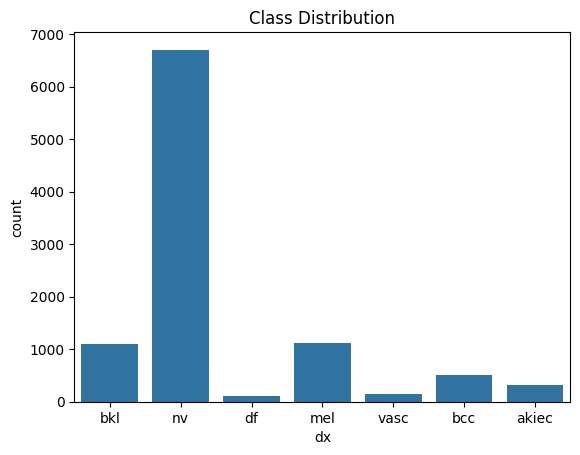

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['dx'])
plt.title("Class Distribution")
plt.show()


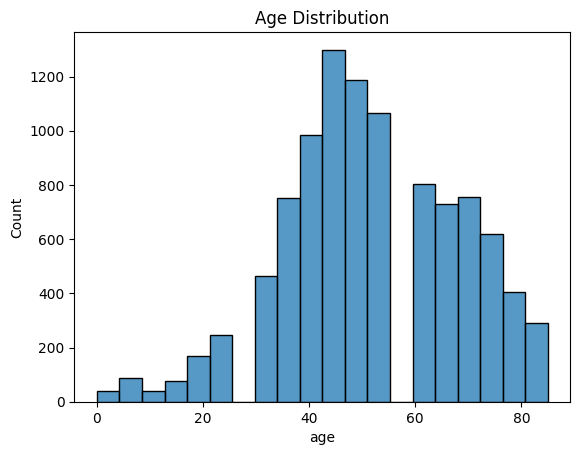

In [ ]:
# Age distribution
sns.histplot(df['age'], bins=20)
plt.title("Age Distribution")
plt.show()

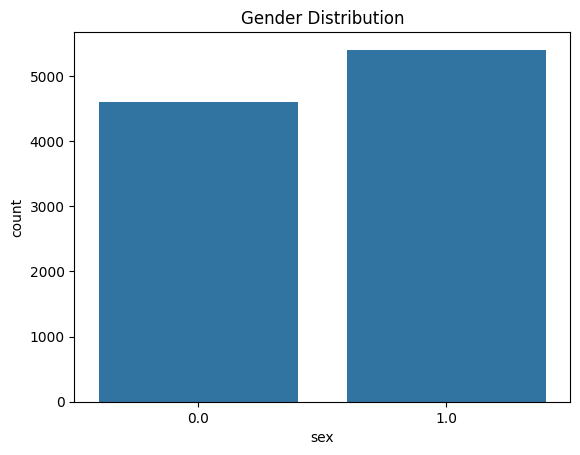

In [ ]:
# Gender
sns.countplot(x=df['sex'])
plt.title("Gender Distribution")
plt.show()

In [ ]:
import os

# remove missing image rows
df = df[df['path'].apply(os.path.exists)].reset_index(drop=True)

print("Remaining images:", len(df))

Remaining images: 7084


TRAIN / VALID / TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'])
valid_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'])

DATASET + AUGMENTATION

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np

train_transform = A.Compose([
    A.Resize(224,224),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Rotate(limit=20,p=0.5),
    A.Normalize(mean=(0.485,0.456,0.406),
                std=(0.229,0.224,0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(224,224),
    A.Normalize(mean=(0.485,0.456,0.406),
                std=(0.229,0.224,0.225)),
    ToTensorV2()
])

class HAMDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if not os.path.exists(row['path']):
            print("Missing file:", row['path'])
            return self.__getitem__((idx + 1) % len(self.df))

        image = Image.open(row['path']).convert("RGB")
        image = self.transform(image=np.array(image))['image']

        meta = torch.tensor([row['age'], row['sex'], row['localization']], dtype=torch.float32)
        label = torch.tensor(row['label']).long()

        return image, meta, label

DATALOADERS

In [ ]:
train_loader = DataLoader(HAMDataset(train_df, train_transform), batch_size=32, shuffle=True)
valid_loader = DataLoader(HAMDataset(valid_df, val_transform), batch_size=32)
test_loader  = DataLoader(HAMDataset(test_df, val_transform), batch_size=32)

MODEL

In [ ]:
import torchvision.models as models
import torch.nn as nn

class MultiModalModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.image_model = models.efficientnet_b0(weights="IMAGENET1K_V1")
        self.image_model.classifier[1] = nn.Linear(1280,128)

        self.meta_model = nn.Sequential(
            nn.Linear(3,64),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Linear(192,64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64,7)
        )

    def forward(self, image, meta):
        img_feat = self.image_model(image)
        meta_feat = self.meta_model(meta)
        return self.classifier(torch.cat((img_feat, meta_feat),1))

TRAINING

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultiModalModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

train_loss, val_loss = [], []

for epoch in range(10):
    model.train()
    total_loss = 0

    for img, meta, label in train_loader:
        img, meta, label = img.to(device), meta.to(device), label.to(device)

        optimizer.zero_grad()
        out = model(img, meta)
        loss = criterion(out, label)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss.append(total_loss)

    model.eval()
    val_total = 0
    with torch.no_grad():
        for img, meta, label in valid_loader:
            img, meta, label = img.to(device), meta.to(device), label.to(device)
            val_total += criterion(model(img, meta), label).item()

    val_loss.append(val_total)

    print(f"Epoch {epoch+1}: Train={total_loss:.2f}, Val={val_total:.2f}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 83.7MB/s]


Epoch 1: Train=254.16, Val=17.78
Epoch 2: Train=141.63, Val=14.82
Epoch 3: Train=112.54, Val=12.97
Epoch 4: Train=95.22, Val=11.25
Epoch 5: Train=78.73, Val=11.03
Epoch 6: Train=66.77, Val=11.25
Epoch 7: Train=57.62, Val=10.75
Epoch 8: Train=48.74, Val=10.21
Epoch 9: Train=43.56, Val=11.12
Epoch 10: Train=37.70, Val=10.84


LOSS CURVE

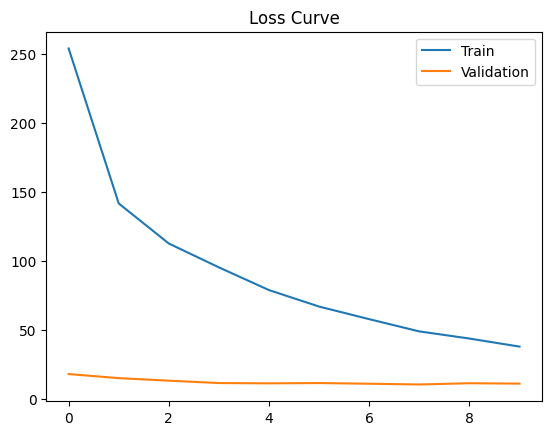

In [ ]:
plt.plot(train_loss,label="Train")
plt.plot(val_loss,label="Validation")
plt.legend()
plt.title("Loss Curve")
plt.show()

EVALUATION + CONFUSION MATRIX

In [ ]:
class_names = df.sort_values("label")["dx"].unique()

Accuracy: 0.8519040902679831


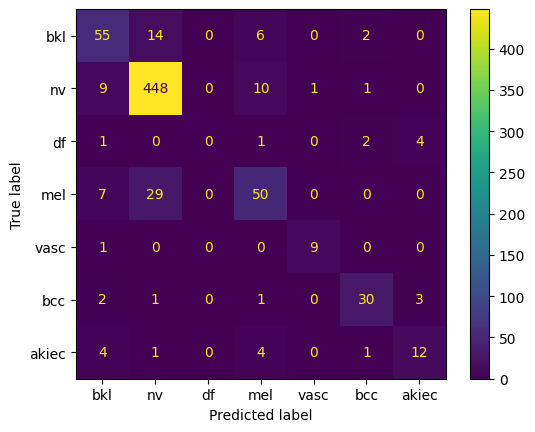

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

model.eval()
preds, labels_all = [], []

with torch.no_grad():
    for img, meta, label in test_loader:
        img, meta = img.to(device), meta.to(device)
        out = model(img, meta)
        _, pred = torch.max(out,1)

        preds.extend(pred.cpu().numpy())
        labels_all.extend(label.numpy())

print("Accuracy:", accuracy_score(labels_all, preds))

ConfusionMatrixDisplay(confusion_matrix(labels_all, preds),
                       display_labels=class_names).plot()

GRAD-CAM (EXPLAINABILITY)

In [ ]:
class ImageOnlyModel(torch.nn.Module):
    def __init__(self, model, meta_sample):
        super().__init__()
        self.model = model
        self.meta_sample = meta_sample  # fixed metadata

    def forward(self, x):
        return self.model(x, self.meta_sample)

In [ ]:
class ImageOnlyModel(torch.nn.Module):
    def __init__(self, model, meta_sample):
        super().__init__()
        self.model = model
        self.meta_sample = meta_sample  # fixed metadata

    def forward(self, x):
        return self.model(x, self.meta_sample)

In [ ]:
wrapped_model = ImageOnlyModel(model, meta)
wrapped_model.eval()

ImageOnlyModel(
  (model): MultiModalModel(
    (image_model): EfficientNet(
      (features): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): SiLU(inplace=True)
        )
        (1): Sequential(
          (0): MBConv(
            (block): Sequential(
              (0): Conv2dNormActivation(
                (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
                (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                (2): SiLU(inplace=True)
              )
              (1): SqueezeExcitation(
                (avgpool): AdaptiveAvgPool2d(output_size=1)
                (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
                (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

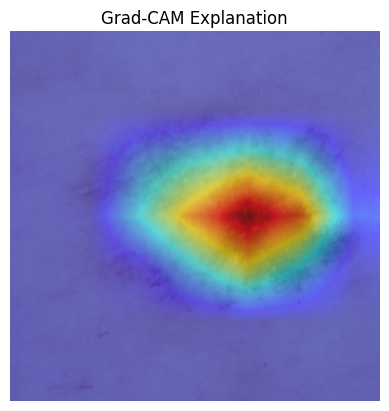

In [ ]:
import torch
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np

# Re-define ImageOnlyModel within this cell to ensure meta_sample device consistency
class ImageOnlyModel(torch.nn.Module):
    def __init__(self, model, meta_sample):
        super().__init__()
        self.model = model
        # Detach and clone meta_sample to ensure it's a new tensor and not linked to computation graph
        # It will be moved to the correct device in the forward pass.
        self.meta_sample = meta_sample.detach().clone()

    def forward(self, x):
        # Ensure self.meta_sample is on the same device as x (the image input)
        meta_on_x_device = self.meta_sample.to(x.device)
        return self.model(x, meta_on_x_device)

target_layer = model.image_model.features[-1]

# Get one batch of data for example
example_images, example_meta, _ = next(iter(test_loader))

# Select the first image and its corresponding meta-data from the batch
input_img_for_cam = example_images[0].unsqueeze(0).to(device)
input_meta_for_cam = example_meta[0].unsqueeze(0).to(device)

# Instantiate wrapped_model with this specific meta:
wrapped_model = ImageOnlyModel(model, input_meta_for_cam)
wrapped_model.eval()

cam = GradCAM(model=wrapped_model, target_layers=[target_layer])

grayscale_cam = cam(input_tensor=input_img_for_cam)[0]

# Convert image for display
img_np = input_img_for_cam.squeeze().permute(1,2,0).cpu().numpy()

# De-normalize (IMPORTANT for visualization)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = std * img_np + mean
img_np = np.clip(img_np, 0, 1)

# Overlay heatmap
vis = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

plt.imshow(vis)
plt.title("Grad-CAM Explanation")
plt.axis('off')

Multiple GRAD CAM Samples

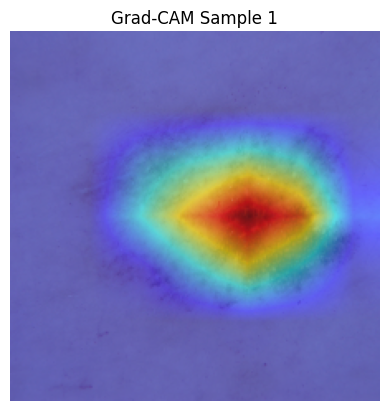

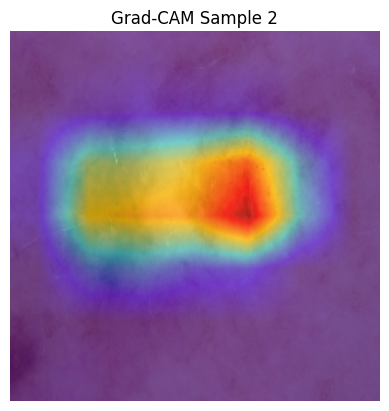

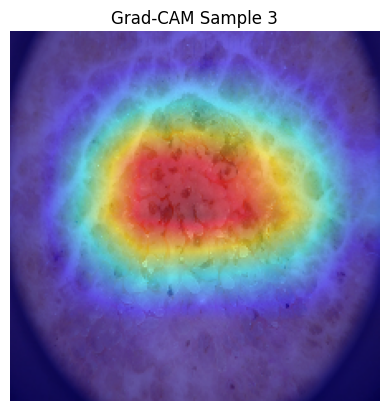

In [ ]:
for i in range(3):
    img, meta, label = next(iter(test_loader))

    img = img[i].unsqueeze(0).to(device)
    meta = meta[i].unsqueeze(0).to(device)

    wrapped_model = ImageOnlyModel(model, meta)

    cam = GradCAM(model=wrapped_model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=img)[0]

    img_np = img.squeeze().permute(1,2,0).cpu().numpy()
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    vis = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    plt.imshow(vis)
    plt.title(f"Grad-CAM Sample {i+1}")
    plt.axis('off')
    plt.show()

SAMPLE PREDICTION

In [ ]:
model.eval()

img, meta, label = next(iter(test_loader))

img = img[0].unsqueeze(0).to(device)
meta = meta[0].unsqueeze(0).to(device)

with torch.no_grad():
    output = model(img, meta)
    _, pred = torch.max(output, 1)

true_label = class_names[label[0].item()]
pred_label = class_names[pred.item()]

print(" True Label:", true_label)
print(" Predicted Label:", pred_label)


 True Label: nv
 Predicted Label: nv


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

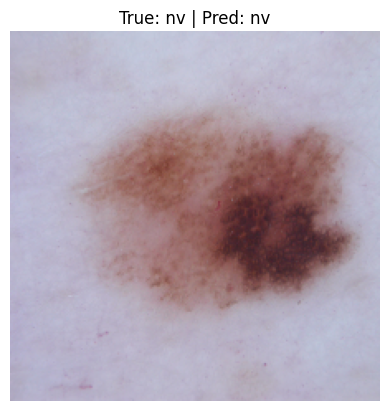

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

img_np = img.squeeze().permute(1,2,0).cpu().numpy()

# De-normalize
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = std * img_np + mean
img_np = np.clip(img_np, 0, 1)

plt.imshow(img_np)
plt.title(f"True: {true_label} | Pred: {pred_label}")
plt.axis('off')

CONFIDENCE SCORE

In [ ]:
prob = torch.nn.functional.softmax(output, dim=1)
confidence = prob[0][pred.item()].item()

print(f"Confidence: {confidence:.2f}")

Confidence: 1.00
